In [2]:
# Numpy
import numpy as np

# Matplotlib
import matplotlib.pyplot as plt 
import matplotlib.lines as mlines
plt.style.use('my_style')

# Astropy
from astropy import units as u

# Importlib
import importlib

# Pickle for saving dictionaries
import pickle

# Other modules
# import metal_equilibrium_varyPSA as met_varyPSA
# import metallicity_code as metal_code
import metallicity_code_varyMdotacc as metal_code_varyMdotacc

In [3]:
importlib.reload(metal_code_varyMdotacc)

<module 'metallicity_code_varyMdotacc' from "c:\\Users\\melec\\OneDrive - Universiteit Leiden\\Documents\\Leiden University\\Second Year\\Master's Research Project\\Project Code\\metallicity_code_varyMdotacc.py">

- Run disk code for Mh01e12 
- Use disk code outputs as initial values to function that calcules metallicity with P,S,A as free parameters. Run the metallicity code for various values of either P,S,A while you fix the rest. Each run will give a dict of metallicity code parameters and I can use my method of determining which gradients are from profiles that are in equilibrium

# Getting disk code outputs to use for initial guesses

In [4]:
# # Running galactic disk code from redshift 4 to 0
# z_init=4
# z_final=0
# logMhz_final=12
# etaw_const=0
# etaw_option='constant'
# beta_const=0
# beta_option='varying'
# xi_const=0.2
# xi_option='varying'
# Mdotacc_option='original'

# disk_outputs_Mh01e12_originalMdotacc_nooutflows = metal_code_varyMdotacc.disc_code_outputs(z_init=z_init, z_final=z_final, logMhz_final=logMhz_final, 
#                                                                                            etaw_const=etaw_const, etaw_option=etaw_option, beta_const=beta_const,
#                                                                                            beta_option=beta_option, xi_const=xi_const, xi_option=xi_option, 
#                                                                                            Mdotacc_option=Mdotacc_option)

# # Saving dict
# file = open('Data/galactic_disc_varyMdotacc/disk_outputs_Mh01e12_z=4-0_Mdotacc=original_etaw=0.p', 'wb')
# pickle.dump(disk_outputs_Mh01e12_originalMdotacc_nooutflows, file, protocol=pickle.HIGHEST_PROTOCOL)

# z_init=4
# z_final=0
# logMhz_final=11
# etaw_const=0
# etaw_option='constant'
# beta_const=0
# beta_option='varying'
# xi_const=0.2
# xi_option='varying'
# Mdotacc_option='original'

# disk_outputs_Mh01e11_originalMdotacc_nooutflows = metal_code_varyMdotacc.disc_code_outputs(z_init=z_init, z_final=z_final, logMhz_final=logMhz_final, 
#                                                                                            etaw_const=etaw_const, etaw_option=etaw_option, beta_const=beta_const,
#                                                                                            beta_option=beta_option, xi_const=xi_const, xi_option=xi_option, 
#                                                                                            Mdotacc_option=Mdotacc_option)

# # Saving dict
# file = open('Data/galactic_disc_varyMdotacc/disk_outputs_Mh01e11_z=4-0_Mdotacc=original_etaw=0.p', 'wb')
# pickle.dump(disk_outputs_Mh01e11_originalMdotacc_nooutflows, file, protocol=pickle.HIGHEST_PROTOCOL)

In [5]:
# Loading dict
# file = open('Data/galactic_disc_varyMdotacc/disk_outputs_Mh01e12_z=4-0_Mdotacc=original_etaw=0.p', 'rb')
# disk_outputs_Mh01e12_originalMdotacc_nooutflows= pickle.load(file)
# file.close()

# file = open('Data/galactic_disc_varyMdotacc/disk_outputs_Mh01e11_z=4-0_Mdotacc=original_etaw=0.p', 'rb')
# disk_outputs_Mh01e11_originalMdotacc_nooutflows= pickle.load(file)
# file.close()

file = open('Data/galactic_disc_varyMdotacc/disc_outputs_Mh01e12_original_HH17_z=4-0.p', 'rb')
disk_outputs_Mh01e12_originalMdotacc_HH17 = pickle.load(file)
file.close()

file = open('Data/galactic_disc_varyMdotacc/disc_outputs_Mh01e11_original_HH17_z=4-0.p', 'rb')
disk_outputs_Mh01e11_originalMdotacc_HH17 = pickle.load(file)
file.close()

# 1. Varying $\mathcal{P}$ 
- Focusing on $M_{\mathrm{h,0}} = 10^{12}\:\mathrm{M}_{\odot}$ at $z = 0$ with no outflows
- For parameters that I am not varying, going to use the parameters from the galactic disc code

In [6]:
# Mh01e12
# Take disc parameters at z=0
z_arr = disk_outputs_Mh01e12_originalMdotacc_HH17['z']
z_given = 0
z_index = np.abs(z_arr-z_given).argmin()

# Take P = 0 as initial guess, generate arbitrary array of P values and fix other parameters
P_guess = disk_outputs_Mh01e12_originalMdotacc_HH17['P'][z_index]
P_Mh01e12_arr = np.linspace(P_guess, 100, 100)
S_fix = disk_outputs_Mh01e12_originalMdotacc_HH17["Sprime_Toomre"][z_index] * (1*0.028/0.0134) # Multiply Sprime_Toomre by phiy*y/solarZ
                                                                                            # Chose S_Toomre since S_Toomre used to calculate Zr0 
A_fix = disk_outputs_Mh01e12_originalMdotacc_HH17["A"][z_index]

metal_outputs_Mh01e12_originalMdotacc_HH17_varyP = {} # Key: A
                                                            # Returns: normZ_func dict output

# Run each P through metallicity code
for P in P_Mh01e12_arr:
    # print(P)
    metal_outputs = metal_code_varyMdotacc.normZ_func_varyPSA(disk_code_outputs=disk_outputs_Mh01e12_originalMdotacc_HH17, z_given=z_given, P=P, S=S_fix, A=A_fix)
    metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P] = metal_outputs

# -----------------------------------------
# Mh01e11
# Take disc parameters at z=0
z_arr = disk_outputs_Mh01e11_originalMdotacc_HH17['z']
z_given = 0
z_index = np.abs(z_arr-z_given).argmin()

# Take P = 0 as initial guess, generate arbitrary array of P values and fix other parameters
P_guess = disk_outputs_Mh01e11_originalMdotacc_HH17['P'][z_index]
P_Mh01e11_arr = np.linspace(P_guess, 200, 100)
S_fix = disk_outputs_Mh01e11_originalMdotacc_HH17["Sprime_Toomre"][z_index] * (1*0.028/0.0134) # Multiply Sprime_Toomre by phiy*y/solarZ
                                                                                            # Chose S_Toomre since S_Toomre used to calculate Zr0 
A_fix = disk_outputs_Mh01e11_originalMdotacc_HH17["A"][z_index]

metal_outputs_Mh01e11_originalMdotacc_HH17_varyP = {} # Key: P
                                                            # Returns: normZ_func dict output

# Run each P through metallicity code
for P in P_Mh01e11_arr:
    # print(P)
    metal_outputs = metal_code_varyMdotacc.normZ_func_varyPSA(disk_code_outputs=disk_outputs_Mh01e11_originalMdotacc_HH17, z_given=z_given, P=P, S=S_fix, A=A_fix)
    metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P] = metal_outputs

Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre,

In [7]:
print(A_fix)

24.211231546919702


In [8]:
# # Saving dict 
# file = (open('Data/metallicity_varyMdotacc/metal_output_varyP_key=P_logMhzfinal=12_z=0_Mdotacc=original_etaw=0.p', 'wb'))
# pickle.dump(metal_outputs_Mh01e12_originalMdotacc_nooutflows_varyP, file, protocol=pickle.HIGHEST_PROTOCOL)
# file.close()

# file = (open('Data/metallicity_varyMdotacc/metal_output_varyP_key=P_logMhzfinal=11_z=0_Mdotacc=original_etaw=0.p', 'wb'))
# pickle.dump(metal_outputs_Mh01e11_originalMdotacc_nooutflows_varyP, file, protocol=pickle.HIGHEST_PROTOCOL)
# file.close()

In [9]:
# # Loading dict 
# file = (open('Data/metallicity_varyMdotacc/metal_output_varyP_key=P_logMhzfinal=12_z=0_Mdotacc=original_etaw=0.p', 'rb'))
# metal_outputs_Mh01e12_originalMdotacc_nooutflows_varyP = pickle.load(file)
# file.close()

# file = (open('Data/metallicity_varyMdotacc/metal_output_varyP_key=P_logMhzfinal=11_z=0_Mdotacc=original_etaw=0.p', 'rb'))
# metal_outputs_Mh01e11_originalMdotacc_nooutflows_varyP = pickle.load(file)
# file.close()

In [10]:
metgrad_ineq_Mh01e12_varyP = {} # metgrad vs. P
metgrad_ineq_Mh01e11_varyP = {}

for P_Mh01e12, P_Mh01e11 in zip(P_Mh01e12_arr, P_Mh01e11_arr):
    # ------------- Mh01e12 --------------------------
    # Parameters needed to calculate family of curves
    x = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['x']
    regime = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['regime']
    Zr0_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['Zr0_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['Zr0_max'][0]) # Zr0 the same even if disk both in Toomre and GMC regime
    P = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['P']
    A = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['A']
    # S_GMC = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P]['S_GMC']
    # S_Toomre = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P]['S_Toomre']
    S_GMC = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['S'] # Since we fix S use the same for S_GMC and S_Toomre
    S_Toomre = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['S']
    T = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['T']
    x_b = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['x_b']
    beta = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['beta']
    Omega0 = metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['Omega0']

    # Generate range of c1min and c1max based on regime
    if regime == 'GMC':
        c1_GMC_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['c1_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['c1_max'][0])
        c1_Toomre_range = np.zeros_like(c1_GMC_range)
    elif regime == 'Toomre':
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['c1_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['c1_max'][0])
        c1_GMC_range = np.zeros_like(c1_Toomre_range)
    else:
        c1_GMC_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['c1_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['c1_max'][0])
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['c1_min'][1], metal_outputs_Mh01e12_originalMdotacc_HH17_varyP[P_Mh01e12]['c1_max'][1])

    metgrad_varyP_arr = [] # [metgrad_min, metgrad_max] 

    # Loop over range of c1_Toomre, c1_GMC and Zr0 values
    metgrad_prev = 0 # To track the value of metgrad for previous c1 Toomre, c1 GMC, Zr0
    for i, c1_Toomre, c1_GMC, Zr0 in zip(range(len(c1_Toomre_range)), c1_Toomre_range, c1_GMC_range, Zr0_range):
        _, teqbm, metgrad = metal_code_varyMdotacc.generate_curve(regime=regime, c1_Toomre=c1_Toomre, c1_GMC=c1_GMC, Zr0=Zr0, P=P, S_Toomre=S_Toomre, S_GMC=S_GMC, A=A, T=T, x=x, xmax=x[-1], x_b=x_b, beta=beta, Omega0=Omega0)

        # To find metgrad_max need to find the last profile in equilibrium - apply equilibrium criterion
        diff = teqbm.to('Gyr').value - 2 # Calculating teqbm-tdep in Gyr with tdep = 2 Gyr
        N_outofeq = len(x[np.where(diff > 0.5)]) 

        # Save metgrad_min for first c1_Toomre, c1_GMC, Zr0 - safe to assume that profile corresponding to c1_min is in equilibrium, but check anyways
        if i == 0:
            # Check if this profile is in equilibrium by applying our criterion - out of equilibrium if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            if N_outofeq > 100: 
                # print(f'No profile in equilibrium for logMstar={logMstar}: N_outofeq={N_outofeq}')
                break
            else:
                # print(f'First profile is in equilibrium: N_outofeq={N_outofeq}')
                metgrad_varyP_arr.append(metgrad)
                metgrad_prev = metgrad # Track value of previous metgrad
                continue

        if N_outofeq > 100: # Our profile equilibrium criterion is if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            # print(f'Profile for logMstar={logMstar}, c1_Toomre={c1_Toomre}, c1_GMC={c1_GMC}, Zr0={Zr0}, out of equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyP_arr.append(metgrad_prev) # If profile for current c1, Zr0 out of equilibrium, then metgrad from previous c1, Zr0 value was last one in equilibrium
            break
        else:
            metgrad_prev = metgrad # Keep previous metgrad before continuing to next c1, Zr0 values

        # If every curve is in equilibrium take the last profile to be in equilibrium
        if i == range(len(c1_Toomre_range))[-1]: 
            # print(f'Every profile is in equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyP_arr .append(metgrad) # Pppend metgrad for that last profile

    metgrad_ineq_Mh01e12_varyP[P_Mh01e12] = metgrad_varyP_arr

    # ------------------ Mh01e11 -------------------------------
    # Parameters needed to calculate family of curves
    x = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['x']
    regime = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['regime']
    Zr0_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['Zr0_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['Zr0_max'][0]) # Zr0 the same even if disk both in Toomre and GMC regime
    P = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['P']
    A = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['A']
    # S_GMC = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P]['S_GMC']
    # S_Toomre = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P]['S_Toomre']
    S_GMC = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['S'] # Since we fix S use the same for S_GMC and S_Toomre
    S_Toomre = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['S']
    T = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['T']
    x_b = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['x_b']
    beta = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['beta']
    Omega0 = metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['Omega0']

    # Generate range of c1min and c1max based on regime
    if regime == 'GMC':
        c1_GMC_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['c1_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['c1_max'][0])
        c1_Toomre_range = np.zeros_like(c1_GMC_range)
    elif regime == 'Toomre':
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['c1_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['c1_max'][0])
        c1_GMC_range = np.zeros_like(c1_Toomre_range)
    else:
        c1_GMC_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['c1_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['c1_max'][0])
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['c1_min'][1], metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['c1_max'][1])

    metgrad_varyP_arr = [] # [metgrad_min, metgrad_max] 

    # Loop over range of c1_Toomre, c1_GMC and Zr0 values
    metgrad_prev = 0 # To track the value of metgrad for previous c1 Toomre, c1 GMC, Zr0
    for i, c1_Toomre, c1_GMC, Zr0 in zip(range(len(c1_Toomre_range)), c1_Toomre_range, c1_GMC_range, Zr0_range):
        _, teqbm, metgrad = metal_code_varyMdotacc.generate_curve(regime=regime, c1_Toomre=c1_Toomre, c1_GMC=c1_GMC, Zr0=Zr0, P=P, S_Toomre=S_Toomre, S_GMC=S_GMC, A=A, T=T, x=x, xmax=x[-1], x_b=x_b, beta=beta, Omega0=Omega0)

        # To find metgrad_max need to find the last profile in equilibrium - apply equilibrium criterion
        diff = teqbm.to('Gyr').value - 2 # Calculating teqbm-tdep in Gyr with tdep = 2 Gyr
        N_outofeq = len(x[np.where(diff > 0.5)]) 

        # Save metgrad_min for first c1_Toomre, c1_GMC, Zr0 - safe to assume that profile corresponding to c1_min is in equilibrium, but check anyways
        if i == 0:
            print(metgrad, metal_outputs_Mh01e11_originalMdotacc_HH17_varyP[P_Mh01e11]['metgrad_min'])
            # Check if this profile is in equilibrium by applying our criterion - out of equilibrium if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            if N_outofeq > 100: 
                # print(f'No profile in equilibrium for logMstar={logMstar}: N_outofeq={N_outofeq}')
                break
            else:
                print(f'First profile is in equilibrium: N_outofeq={N_outofeq}')
                metgrad_varyP_arr.append(metgrad)
                metgrad_prev = metgrad # Track value of previous metgrad
                continue

        if N_outofeq > 100: # Our profile equilibrium criterion is if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            # print(f'Profile for logMstar={logMstar}, c1_Toomre={c1_Toomre}, c1_GMC={c1_GMC}, Zr0={Zr0}, out of equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyP_arr.append(metgrad_prev) # If profile for current c1, Zr0 out of equilibrium, then metgrad from previous c1, Zr0 value was last one in equilibrium
            break
        else:
            metgrad_prev = metgrad # Keep previous metgrad before continuing to next c1, Zr0 values

        # If every curve is in equilibrium take the last profile to be in equilibrium
        if i == range(len(c1_Toomre_range))[-1]: 
            print(f'Every profile is in equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyP_arr .append(metgrad) # Pppend metgrad for that last profile

    metgrad_ineq_Mh01e11_varyP[P_Mh01e11] = metgrad_varyP_arr


-0.09193364770162425 -0.09193364770162425
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
-0.09169122017267135 -0.09169122017267135
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
-0.0914495441504437 -0.0914495441504437
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
-0.09120863112270952 -0.09120863112270952
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
-0.09096849186764643 -0.09096849186764643
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
-0.09072913648562543 -0.09072913648562543
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
-0.09049057442950993 -0.09049057442950993
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
-0.09025281453357241 -0.09025281453357241
First profile is in equilibrium: N_o

C:\Users\melec\AppData\Local\Temp\ipykernel_16984\1587696350.py:16: RuntimeWarning: divide by zero encountered in log10
  ax[0].plot(np.log10(P_Mh01e12_arr), metgrad_ineq_Mh01e12_varyP_min)
C:\Users\melec\AppData\Local\Temp\ipykernel_16984\1587696350.py:17: RuntimeWarning: divide by zero encountered in log10
  ax[0].plot(np.log10(P_Mh01e12_arr), metgrad_ineq_Mh01e12_varyP_max)


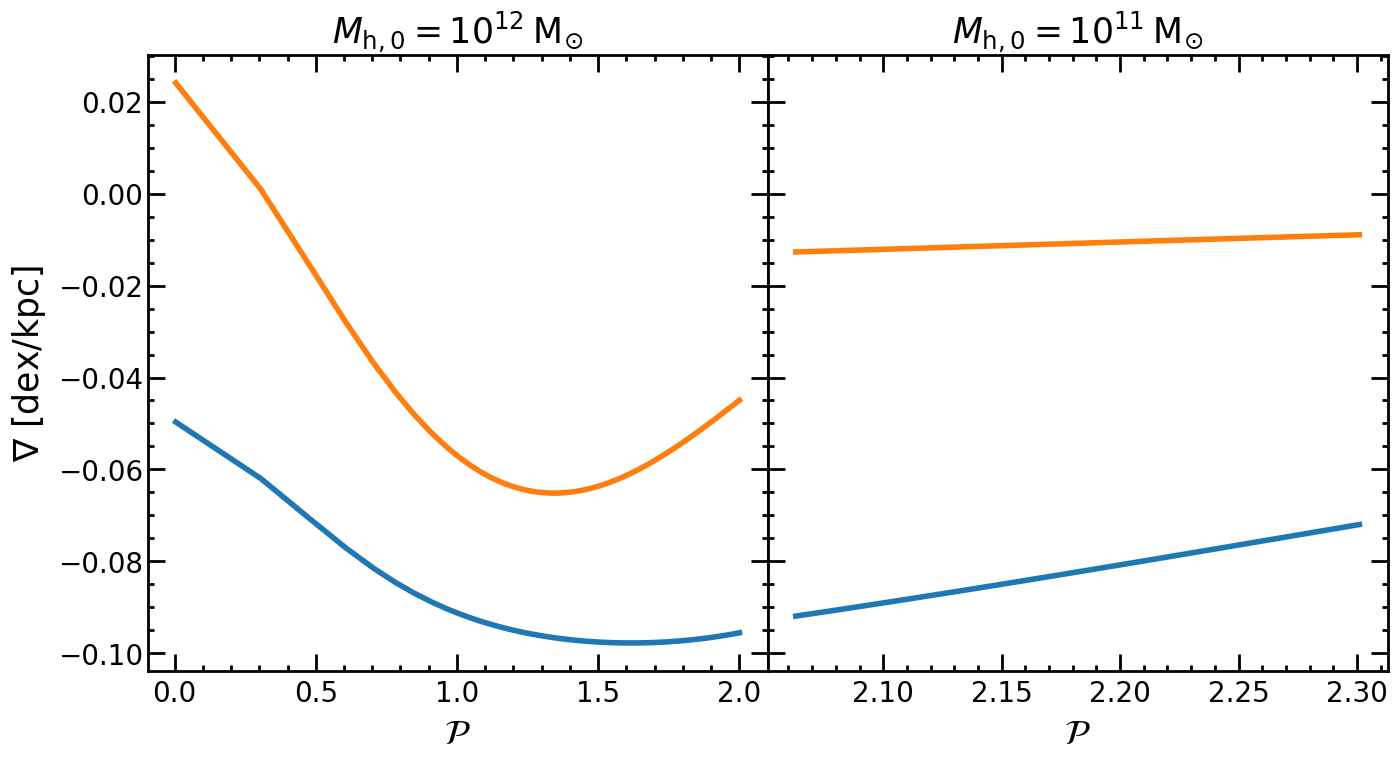

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(16,8), sharey = True)

metgrad_ineq_Mh01e12_varyP_min = []
metgrad_ineq_Mh01e12_varyP_max = []

metgrad_ineq_Mh01e11_varyP_min = []
metgrad_ineq_Mh01e11_varyP_max = []

for P_Mh01e12, P_Mh01e11 in zip(P_Mh01e12_arr, P_Mh01e11_arr):
    metgrad_ineq_Mh01e12_varyP_min.append(metgrad_ineq_Mh01e12_varyP[P_Mh01e12][0])
    metgrad_ineq_Mh01e12_varyP_max.append(metgrad_ineq_Mh01e12_varyP[P_Mh01e12][1])

    metgrad_ineq_Mh01e11_varyP_min.append(metgrad_ineq_Mh01e11_varyP[P_Mh01e11][0])
    metgrad_ineq_Mh01e11_varyP_max.append(metgrad_ineq_Mh01e11_varyP[P_Mh01e11][1])

ax[0].plot(np.log10(P_Mh01e12_arr), metgrad_ineq_Mh01e12_varyP_min)
ax[0].plot(np.log10(P_Mh01e12_arr), metgrad_ineq_Mh01e12_varyP_max)
# ax[0].fill_between(P_Mh01e12_arr, metgrad_ineq_Mh01e12_varyP_min, metgrad_ineq_Mh01e12_varyP_max, color='tab:olive', alpha = 0.5)
ax[0].set_title(r'$M_{\mathrm{h,0}}=10^{12}\:\rm M_{\odot}$')
ax[0].set_ylabel(r'$\nabla$ [dex/kpc]')
ax[0].set_xlabel(r'$\mathcal{P}$')

ax[1].plot(np.log10(P_Mh01e11_arr), metgrad_ineq_Mh01e11_varyP_min)
ax[1].plot(np.log10(P_Mh01e11_arr), metgrad_ineq_Mh01e11_varyP_max)
ax[1].set_title(r'$M_{\mathrm{h,0}}=10^{11}\:\rm M_{\odot}$')
ax[1].set_xlabel(r'$\mathcal{P}$')

plt.subplots_adjust(wspace=0)
plt.show(True)

# 2. Varying $\mathcal{A}$ only

In [12]:
# Mh01e12
# Take disc parameters at z=0
z_arr = disk_outputs_Mh01e12_originalMdotacc_HH17['z']
z_given = 0
z_index = np.abs(z_arr-z_given).argmin()

# Take P = 0 as initial guess, generate arbitrary array of P values and fix other parameters
P_fix = disk_outputs_Mh01e12_originalMdotacc_HH17['P'][z_index]
S_fix = disk_outputs_Mh01e12_originalMdotacc_HH17["Sprime_Toomre"][z_index] * (1*0.028/0.0134) # Multiply Sprime_Toomre by phiy*y/solarZ
                                                                                            # Chose S_Toomre since S_Toomre used to calculate Zr0 
A_guess = disk_outputs_Mh01e12_originalMdotacc_HH17["A"][z_index]
A_Mh01e12_arr = np.linspace(A_guess, 100, 100)


metal_outputs_Mh01e12_originalMdotacc_HH17_varyA = {} # Key: A
                                                            # Returns: normZ_func dict output

# Run each P through metallicity code
for A in A_Mh01e12_arr:
    # print(P)
    metal_outputs = metal_code_varyMdotacc.normZ_func_varyPSA(disk_code_outputs=disk_outputs_Mh01e12_originalMdotacc_HH17, z_given=z_given, P=P_fix, S=S_fix, A=A)
    metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A] = metal_outputs

# -----------------------------------------
# Mh01e11
# Take disc parameters at z=0
z_arr = disk_outputs_Mh01e11_originalMdotacc_HH17['z']
z_given = 0
z_index = np.abs(z_arr-z_given).argmin()

# Take P = 0 as initial guess, generate arbitrary array of P values and fix other parameters
P_fix = disk_outputs_Mh01e11_originalMdotacc_HH17['P'][z_index]
S_fix = disk_outputs_Mh01e11_originalMdotacc_HH17["Sprime_Toomre"][z_index] * (1*0.028/0.0134) # Multiply Sprime_Toomre by phiy*y/solarZ
                                                                                            # Chose S_Toomre since S_Toomre used to calculate Zr0 
A_guess = disk_outputs_Mh01e11_originalMdotacc_HH17["A"][z_index]
A_Mh01e11_arr = np.linspace(A_guess, 100, 100)


metal_outputs_Mh01e11_originalMdotacc_HH17_varyA = {} # Key: A
                                                            # Returns: normZ_func dict output

# Run each P through metallicity code
for A in A_Mh01e11_arr:
    # print(P)
    metal_outputs = metal_code_varyMdotacc.normZ_func_varyPSA(disk_code_outputs=disk_outputs_Mh01e11_originalMdotacc_HH17, z_given=z_given, P=P_fix, S=S_fix, A=A)
    metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A] = metal_outputs

Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre,

In [13]:
# # Saving dict 
# file = (open('Data/metallicity_varyMdotacc/metal_output_varyA_key=A_logMhzfinal=12_z=0_Mdotacc=original_etaw=0.p', 'wb'))
# pickle.dump(metal_outputs_Mh01e12_originalMdotacc_nooutflows_varyA, file, protocol=pickle.HIGHEST_PROTOCOL)
# file.close()

# file = (open('Data/metallicity_varyMdotacc/metal_output_varyA_key=A_logMhzfinal=11_z=0_Mdotacc=original_etaw=0.p', 'wb'))
# pickle.dump(metal_outputs_Mh01e11_originalMdotacc_nooutflows_varyA, file, protocol=pickle.HIGHEST_PROTOCOL)
# file.close()

In [14]:
# # Loading dict 
# file = (open('Data/metallicity_varyMdotacc/metal_output_varyA_key=A_logMhzfinal=12_z=0_Mdotacc=original_etaw=0.p', 'rb'))
# metal_outputs_Mh01e12_originalMdotacc_nooutflows_varyA = pickle.load(file)
# file.close()

# file = (open('Data/metallicity_varyMdotacc/metal_output_varyA_key=A_logMhzfinal=11_z=0_Mdotacc=original_etaw=0.p', 'rb'))
# metal_outputs_Mh01e11_originalMdotacc_nooutflows_varyA = pickle.load(file)
# file.close()

In [15]:
metgrad_ineq_Mh01e12_varyA = {} # metgrad vs. P
metgrad_ineq_Mh01e11_varyA = {}

for A_Mh01e12, A_Mh01e11 in zip(A_Mh01e12_arr, A_Mh01e11_arr):
    # ------------- Mh01e12 --------------------------
    # Parameters needed to calculate family of curves
    x = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['x']
    regime = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['regime']
    Zr0_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['Zr0_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['Zr0_max'][0]) # Zr0 the same even if disk both in Toomre and GMC regime
    P = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['P']
    A = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['A']
    # S_GMC = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[P]['S_GMC']
    # S_Toomre = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[P]['S_Toomre']
    S_GMC = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['S'] # Since we fix S use the same for S_GMC and S_Toomre
    S_Toomre = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['S']
    T = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['T']
    x_b = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['x_b']
    beta = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['beta']
    Omega0 = metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['Omega0']

    # Generate range of c1min and c1max based on regime
    if regime == 'GMC':
        c1_GMC_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['c1_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['c1_max'][0])
        c1_Toomre_range = np.zeros_like(c1_GMC_range)
    elif regime == 'Toomre':
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['c1_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['c1_max'][0])
        c1_GMC_range = np.zeros_like(c1_Toomre_range)
    else:
        c1_GMC_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['c1_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['c1_max'][0])
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['c1_min'][1], metal_outputs_Mh01e12_originalMdotacc_HH17_varyA[A_Mh01e12]['c1_max'][1])

    metgrad_varyA_arr = [] # [metgrad_min, metgrad_max] 

    # Loop over range of c1_Toomre, c1_GMC and Zr0 values
    metgrad_prev = 0 # To track the value of metgrad for previous c1 Toomre, c1 GMC, Zr0
    for i, c1_Toomre, c1_GMC, Zr0 in zip(range(len(c1_Toomre_range)), c1_Toomre_range, c1_GMC_range, Zr0_range):
        _, teqbm, metgrad = metal_code_varyMdotacc.generate_curve(regime=regime, c1_Toomre=c1_Toomre, c1_GMC=c1_GMC, Zr0=Zr0, P=P, S_Toomre=S_Toomre, S_GMC=S_GMC, A=A, T=T, x=x, xmax=x[-1], x_b=x_b, beta=beta, Omega0=Omega0)

        # To find metgrad_max need to find the last profile in equilibrium - apply equilibrium criterion
        diff = teqbm.to('Gyr').value - 2 # Calculating teqbm-tdep in Gyr with tdep = 2 Gyr
        N_outofeq = len(x[np.where(diff > 0.5)]) 

        # Save metgrad_min for first c1_Toomre, c1_GMC, Zr0 - safe to assume that profile corresponding to c1_min is in equilibrium, but check anyways
        if i == 0:
            # Check if this profile is in equilibrium by applying our criterion - out of equilibrium if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            if N_outofeq > 100: 
                # print(f'No profile in equilibrium for logMstar={logMstar}: N_outofeq={N_outofeq}')
                break
            else:
                # print(f'First profile is in equilibrium: N_outofeq={N_outofeq}')
                metgrad_varyA_arr.append(metgrad)
                metgrad_prev = metgrad # Track value of previous metgrad
                continue

        if N_outofeq > 100: # Our profile equilibrium criterion is if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            # print(f'Profile for logMstar={logMstar}, c1_Toomre={c1_Toomre}, c1_GMC={c1_GMC}, Zr0={Zr0}, out of equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyA_arr.append(metgrad_prev) # If profile for current c1, Zr0 out of equilibrium, then metgrad from previous c1, Zr0 value was last one in equilibrium
            break
        else:
            metgrad_prev = metgrad # Keep previous metgrad before continuing to next c1, Zr0 values

        # If every curve is in equilibrium take the last profile to be in equilibrium
        if i == range(len(c1_Toomre_range))[-1]: 
            # print(f'Every profile is in equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyA_arr .append(metgrad) # Append metgrad for that last profile

    metgrad_ineq_Mh01e12_varyA[A_Mh01e12] = metgrad_varyA_arr

    # ------------------ Mh01e11 -------------------------------
    # Parameters needed to calculate family of curves
    x = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['x']
    regime = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['regime']
    Zr0_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['Zr0_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['Zr0_max'][0]) # Zr0 the same even if disk both in Toomre and GMC regime
    P = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['P']
    A = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['A']
    # S_GMC = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[P]['S_GMC']
    # S_Toomre = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[P]['S_Toomre']
    S_GMC = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['S'] # Since we fix S use the same for S_GMC and S_Toomre
    S_Toomre = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['S']
    T = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['T']
    x_b = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['x_b']
    beta = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['beta']
    Omega0 = metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['Omega0']

    # Generate range of c1min and c1max based on regime
    if regime == 'GMC':
        c1_GMC_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['c1_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['c1_max'][0])
        c1_Toomre_range = np.zeros_like(c1_GMC_range)
    elif regime == 'Toomre':
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['c1_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['c1_max'][0])
        c1_GMC_range = np.zeros_like(c1_Toomre_range)
    else:
        c1_GMC_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['c1_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['c1_max'][0])
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['c1_min'][1], metal_outputs_Mh01e11_originalMdotacc_HH17_varyA[A_Mh01e11]['c1_max'][1])

    metgrad_varyA_arr = [] # [metgrad_min, metgrad_max] 

    # Loop over range of c1_Toomre, c1_GMC and Zr0 values
    metgrad_prev = 0 # To track the value of metgrad for previous c1 Toomre, c1 GMC, Zr0
    for i, c1_Toomre, c1_GMC, Zr0 in zip(range(len(c1_Toomre_range)), c1_Toomre_range, c1_GMC_range, Zr0_range):
        _, teqbm, metgrad = metal_code_varyMdotacc.generate_curve(regime=regime, c1_Toomre=c1_Toomre, c1_GMC=c1_GMC, Zr0=Zr0, P=P, S_Toomre=S_Toomre, S_GMC=S_GMC, A=A, T=T, x=x, xmax=x[-1], x_b=x_b, beta=beta, Omega0=Omega0)

        # To find metgrad_max need to find the last profile in equilibrium - apply equilibrium criterion
        diff = teqbm.to('Gyr').value - 2 # Calculating teqbm-tdep in Gyr with tdep = 2 Gyr
        N_outofeq = len(x[np.where(diff > 0.5)]) 

        # Save metgrad_min for first c1_Toomre, c1_GMC, Zr0 - safe to assume that profile corresponding to c1_min is in equilibrium, but check anyways
        if i == 0:
            # Check if this profile is in equilibrium by applying our criterion - out of equilibrium if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            if N_outofeq > 100: 
                # print(f'No profile in equilibrium for logMstar={logMstar}: N_outofeq={N_outofeq}')
                break
            else:
                print(f'First profile is in equilibrium: N_outofeq={N_outofeq}')
                metgrad_varyA_arr.append(metgrad)
                metgrad_prev = metgrad # Track value of previous metgrad
                continue

        if N_outofeq > 100: # Our profile equilibrium criterion is if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            # print(f'Profile for logMstar={logMstar}, c1_Toomre={c1_Toomre}, c1_GMC={c1_GMC}, Zr0={Zr0}, out of equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyA_arr.append(metgrad_prev) # If profile for current c1, Zr0 out of equilibrium, then metgrad from previous c1, Zr0 value was last one in equilibrium
            break
        else:
            metgrad_prev = metgrad # Keep previous metgrad before continuing to next c1, Zr0 values

        # If every curve is in equilibrium take the last profile to be in equilibrium
        if i == range(len(c1_Toomre_range))[-1]: 
            print(f'Every profile is in equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyA_arr .append(metgrad) # Append metgrad for that last profile

    metgrad_ineq_Mh01e11_varyA[A_Mh01e11] = metgrad_varyA_arr


First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First prof

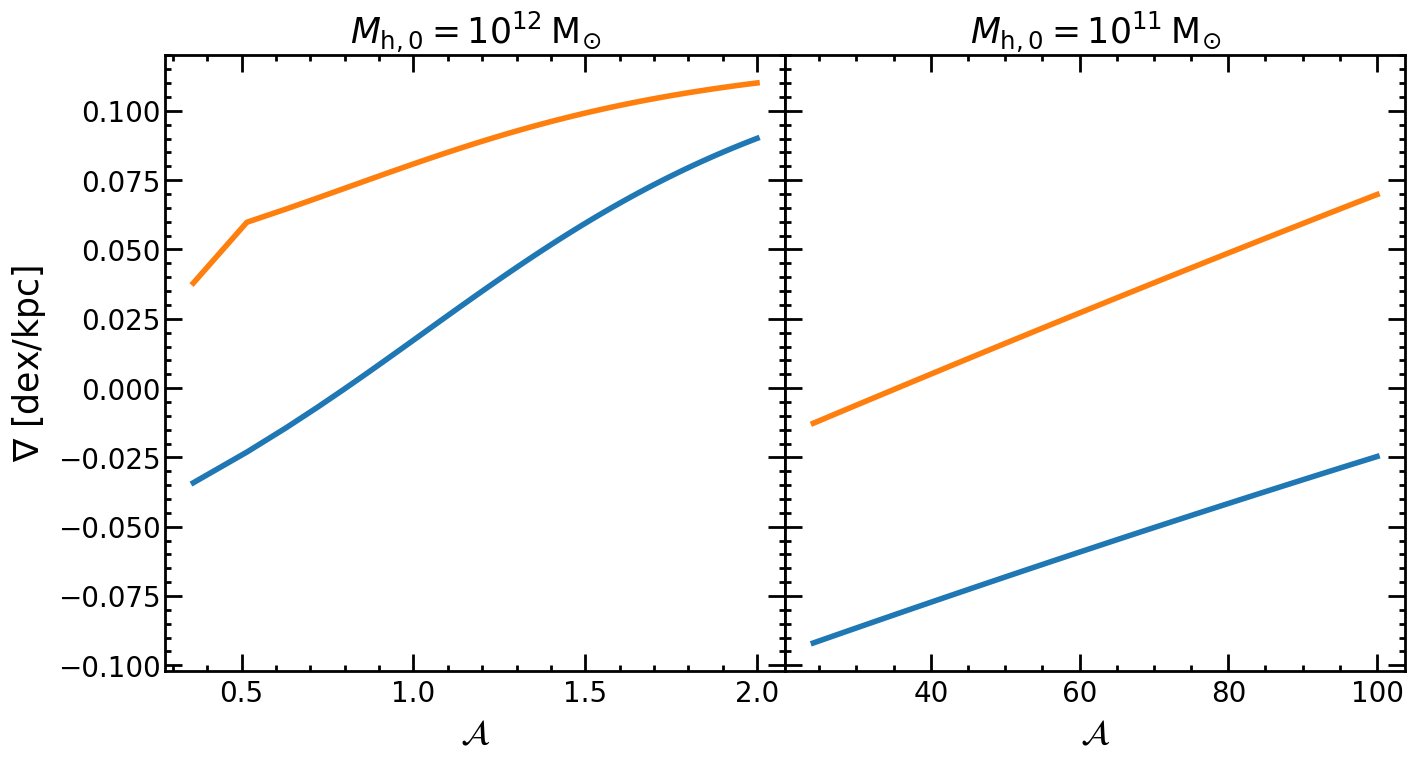

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(16,8), sharey = True)

metgrad_ineq_Mh01e12_varyA_min = []
metgrad_ineq_Mh01e12_varyA_max = []

metgrad_ineq_Mh01e11_varyA_min = []
metgrad_ineq_Mh01e11_varyA_max = []

for A_Mh01e12, A_Mh01e11 in zip(A_Mh01e12_arr, A_Mh01e11_arr):
    metgrad_ineq_Mh01e12_varyA_min.append(metgrad_ineq_Mh01e12_varyA[A_Mh01e12][0])
    metgrad_ineq_Mh01e12_varyA_max.append(metgrad_ineq_Mh01e12_varyA[A_Mh01e12][1])

    metgrad_ineq_Mh01e11_varyA_min.append(metgrad_ineq_Mh01e11_varyA[A_Mh01e11][0])
    metgrad_ineq_Mh01e11_varyA_max.append(metgrad_ineq_Mh01e11_varyA[A_Mh01e11][1])

ax[0].plot(np.log10(A_Mh01e12_arr), metgrad_ineq_Mh01e12_varyA_min)
ax[0].plot(np.log10(A_Mh01e12_arr), metgrad_ineq_Mh01e12_varyA_max)
ax[0].set_title(r'$M_{\mathrm{h,0}}=10^{12}\:\rm M_{\odot}$')
ax[0].set_ylabel(r'$\nabla$ [dex/kpc]')
ax[0].set_xlabel(r'$\mathcal{A}$')

ax[1].plot(A_Mh01e11_arr, metgrad_ineq_Mh01e11_varyA_min)
ax[1].plot(A_Mh01e11_arr, metgrad_ineq_Mh01e11_varyA_max)
ax[1].set_title(r'$M_{\mathrm{h,0}}=10^{11}\:\rm M_{\odot}$')
ax[1].set_xlabel(r'$\mathcal{A}$')

plt.subplots_adjust(wspace=0)
plt.show(True)

# 3. Varying $\mathcal{S}$ only

In [17]:
# Mh01e12
# Take disc parameters at z=0
z_arr = disk_outputs_Mh01e12_originalMdotacc_HH17['z']
z_given = 0
z_index = np.abs(z_arr-z_given).argmin()

# Take P = 0 as initial guess, generate arbitrary array of P values and fix other parameters
P_fix = disk_outputs_Mh01e12_originalMdotacc_HH17['P'][z_index]
S_guess = disk_outputs_Mh01e12_originalMdotacc_HH17["Sprime_Toomre"][z_index] * (1*0.028/0.0134) # Multiply Sprime_Toomre by phiy*y/solarZ
                                                                                            # Chose S_Toomre since S_Toomre used to calculate Zr0 
S_Mh01e12_arr = np.linspace(S_guess, 100, 100)
A_fix = disk_outputs_Mh01e12_originalMdotacc_HH17["A"][z_index]


metal_outputs_Mh01e12_originalMdotacc_HH17_varyS = {} # Key: A
                                                            # Returns: normZ_func dict output

# Run each P through metallicity code
for S in S_Mh01e12_arr:
    # print(P)
    metal_outputs = metal_code_varyMdotacc.normZ_func_varyPSA(disk_code_outputs=disk_outputs_Mh01e12_originalMdotacc_HH17, z_given=z_given, P=P_fix, S=S, A=A_fix)
    metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S] = metal_outputs

# -----------------------------------------
# Mh01e11
# Take disc parameters at z=0
z_arr = disk_outputs_Mh01e11_originalMdotacc_HH17['z']
z_given = 0
z_index = np.abs(z_arr-z_given).argmin()

# Take P = 0 as initial guess, generate arbitrary array of P values and fix other parameters
P_fix = disk_outputs_Mh01e11_originalMdotacc_HH17['P'][z_index]
S_guess = disk_outputs_Mh01e11_originalMdotacc_HH17["Sprime_Toomre"][z_index] * (1*0.028/0.0134) # Multiply Sprime_Toomre by phiy*y/solarZ
                                                                                            # Chose S_Toomre since S_Toomre used to calculate Zr0 
S_Mh01e11_arr = np.linspace(S_guess, 100, 100)
A_guess = disk_outputs_Mh01e11_originalMdotacc_HH17["A"][z_index]


metal_outputs_Mh01e11_originalMdotacc_HH17_varyS = {} # Key: A
                                                            # Returns: normZ_func dict output

# Run each S through metallicity code
for S in S_Mh01e11_arr:
    print(S)
    metal_outputs = metal_code_varyMdotacc.normZ_func_varyPSA(disk_code_outputs=disk_outputs_Mh01e11_originalMdotacc_HH17, z_given=z_given, P=P_fix, S=S, A=A_guess)
    metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S] = metal_outputs

Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre, outer disc is GMC
Zr0 set by source and accretion - Massive galaxy
Inner disc is Toomre,

In [18]:
# # Saving dict 
# file = (open('Data/metallicity_varyMdotacc/metal_output_varyS_key=S_logMhzfinal=12_z=0_Mdotacc=original_etaw=0.p', 'wb'))
# pickle.dump(metal_outputs_Mh01e12_originalMdotacc_nooutflows_varyS, file, protocol=pickle.HIGHEST_PROTOCOL)
# file.close()

# file = (open('Data/metallicity_varyMdotacc/metal_output_varyS_key=S_logMhzfinal=11_z=0_Mdotacc=original_etaw=0.p', 'wb'))
# pickle.dump(metal_outputs_Mh01e11_originalMdotacc_nooutflows_varyS, file, protocol=pickle.HIGHEST_PROTOCOL)
# file.close()

In [19]:
# # Loading dict 
# file = (open('Data/metallicity_varyMdotacc/metal_output_varyS_key=S_logMhzfinal=12_z=0_Mdotacc=original_etaw=0.p', 'rb'))
# metal_outputs_Mh01e12_originalMdotacc_nooutflows_varyS = pickle.load(file)
# file.close()

# file = (open('Data/metallicity_varyMdotacc/metal_output_varyS_key=S_logMhzfinal=11_z=0_Mdotacc=original_etaw=0.p', 'rb'))
# metal_outputs_Mh01e11_originalMdotacc_nooutflows_varyS = pickle.load(file)
# file.close()

In [20]:
metgrad_ineq_Mh01e12_varyS = {} # metgrad vs. P
metgrad_ineq_Mh01e11_varyS = {}

for S_Mh01e12, S_Mh01e11 in zip(S_Mh01e12_arr, S_Mh01e11_arr):
    # ------------- Mh01e12 --------------------------
    # Parameters needed to calculate family of curves
    x = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['x']
    regime = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['regime']
    Zr0_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['Zr0_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['Zr0_max'][0]) # Zr0 the same even if disk both in Toomre and GMC regime
    P = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['P']
    A = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['A']
    # S_GMC = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[P]['S_GMC']
    # S_Toomre = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[P]['S_Toomre']
    S_GMC = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['S'] # Since we fix S use the same for S_GMC and S_Toomre
    S_Toomre = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['S']
    T = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['T']
    x_b = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['x_b']
    beta = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['beta']
    Omega0 = metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['Omega0']

    # Generate range of c1min and c1max based on regime
    if regime == 'GMC':
        c1_GMC_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['c1_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['c1_max'][0])
        c1_Toomre_range = np.zeros_like(c1_GMC_range)
    elif regime == 'Toomre':
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['c1_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['c1_max'][0])
        c1_GMC_range = np.zeros_like(c1_Toomre_range)
    else:
        c1_GMC_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['c1_min'][0], metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['c1_max'][0])
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['c1_min'][1], metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S_Mh01e12]['c1_max'][1])

    metgrad_varyS_arr = [] # [metgrad_min, metgrad_max] 

    # Loop over range of c1_Toomre, c1_GMC and Zr0 values
    metgrad_prev = 0 # To track the value of metgrad for previous c1 Toomre, c1 GMC, Zr0
    for i, c1_Toomre, c1_GMC, Zr0 in zip(range(len(c1_Toomre_range)), c1_Toomre_range, c1_GMC_range, Zr0_range):
        _, teqbm, metgrad = metal_code_varyMdotacc.generate_curve(regime=regime, c1_Toomre=c1_Toomre, c1_GMC=c1_GMC, Zr0=Zr0, P=P, S_Toomre=S_Toomre, S_GMC=S_GMC, A=A, T=T, x=x, xmax=x[-1], x_b=x_b, beta=beta, Omega0=Omega0)

        # To find metgrad_max need to find the last profile in equilibrium - apply equilibrium criterion
        diff = teqbm.to('Gyr').value - 2 # Calculating teqbm-tdep in Gyr with tdep = 2 Gyr
        N_outofeq = len(x[np.where(diff > 0.5)]) 

        # Save metgrad_min for first c1_Toomre, c1_GMC, Zr0 - safe to assume that profile corresponding to c1_min is in equilibrium, but check anyways
        if i == 0:
            # Check if this profile is in equilibrium by applying our criterion - out of equilibrium if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            if N_outofeq > 100: 
                # print(f'No profile in equilibrium for logMstar={logMstar}: N_outofeq={N_outofeq}')
                break
            else:
                # print(f'First profile is in equilibrium: N_outofeq={N_outofeq}')
                metgrad_varyS_arr.append(metgrad)
                metgrad_prev = metgrad # Track value of previous metgrad
                continue

        if N_outofeq > 100: # Our profile equilibrium criterion is if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            # print(f'Profile for logMstar={logMstar}, c1_Toomre={c1_Toomre}, c1_GMC={c1_GMC}, Zr0={Zr0}, out of equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyS_arr.append(metgrad_prev) # If profile for current c1, Zr0 out of equilibrium, then metgrad from previous c1, Zr0 value was last one in equilibrium
            break
        else:
            metgrad_prev = metgrad # Keep previous metgrad before continuing to next c1, Zr0 values

        # If every curve is in equilibrium take the last profile to be in equilibrium
        if i == range(len(c1_Toomre_range))[-1]: 
            # print(f'Every profile is in equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyS_arr .append(metgrad) # Append metgrad for that last profile

    metgrad_ineq_Mh01e12_varyS[S_Mh01e12] = metgrad_varyS_arr

    # ------------------ Mh01e11 -------------------------------
    # Parameters needed to calculate family of curves
    x = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['x']
    regime = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['regime']
    Zr0_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['Zr0_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['Zr0_max'][0]) # Zr0 the same even if disk both in Toomre and GMC regime
    P = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['P']
    A = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['A']
    # S_GMC = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[P]['S_GMC']
    # S_Toomre = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[P]['S_Toomre']
    S_GMC = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['S'] # Since we fix S use the same for S_GMC and S_Toomre
    S_Toomre = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['S']
    T = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['T']
    x_b = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['x_b']
    beta = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['beta']
    Omega0 = metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['Omega0']

    # Generate range of c1min and c1max based on regime
    if regime == 'GMC':
        c1_GMC_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['c1_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['c1_max'][0])
        c1_Toomre_range = np.zeros_like(c1_GMC_range)
    elif regime == 'Toomre':
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['c1_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['c1_max'][0])
        c1_GMC_range = np.zeros_like(c1_Toomre_range)
    else:
        c1_GMC_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['c1_min'][0], metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['c1_max'][0])
        c1_Toomre_range = np.linspace(metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['c1_min'][1], metal_outputs_Mh01e11_originalMdotacc_HH17_varyS[S_Mh01e11]['c1_max'][1])

    metgrad_varyS_arr = [] # [metgrad_min, metgrad_max] 

    # Loop over range of c1_Toomre, c1_GMC and Zr0 values
    metgrad_prev = 0 # To track the value of metgrad for previous c1 Toomre, c1 GMC, Zr0
    for i, c1_Toomre, c1_GMC, Zr0 in zip(range(len(c1_Toomre_range)), c1_Toomre_range, c1_GMC_range, Zr0_range):
        _, teqbm, metgrad = metal_code_varyMdotacc.generate_curve(regime=regime, c1_Toomre=c1_Toomre, c1_GMC=c1_GMC, Zr0=Zr0, P=P, S_Toomre=S_Toomre, S_GMC=S_GMC, A=A, T=T, x=x, xmax=x[-1], x_b=x_b, beta=beta, Omega0=Omega0)

        # To find metgrad_max need to find the last profile in equilibrium - apply equilibrium criterion
        diff = teqbm.to('Gyr').value - 2 # Calculating teqbm-tdep in Gyr with tdep = 2 Gyr
        N_outofeq = len(x[np.where(diff > 0.5)]) 

        # Save metgrad_min for first c1_Toomre, c1_GMC, Zr0 - safe to assume that profile corresponding to c1_min is in equilibrium, but check anyways
        if i == 0:
            # Check if this profile is in equilibrium by applying our criterion - out of equilibrium if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            if N_outofeq > 100: 
                # print(f'No profile in equilibrium for logMstar={logMstar}: N_outofeq={N_outofeq}')
                break
            else:
                print(f'First profile is in equilibrium: N_outofeq={N_outofeq}')
                metgrad_varyS_arr.append(metgrad)
                metgrad_prev = metgrad # Track value of previous metgrad
                continue

        if N_outofeq > 100: # Our profile equilibrium criterion is if there are more than 100 points in teqbm vs x profile that deviate from tdep by 0.5 Gyr
            # print(f'Profile for logMstar={logMstar}, c1_Toomre={c1_Toomre}, c1_GMC={c1_GMC}, Zr0={Zr0}, out of equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyS_arr.append(metgrad_prev) # If profile for current c1, Zr0 out of equilibrium, then metgrad from previous c1, Zr0 value was last one in equilibrium
            break
        else:
            metgrad_prev = metgrad # Keep previous metgrad before continuing to next c1, Zr0 values

        # If every curve is in equilibrium take the last profile to be in equilibrium
        if i == range(len(c1_Toomre_range))[-1]: 
            print(f'Every profile is in equilibrium: N_outofeq={N_outofeq}')
            metgrad_varyS_arr .append(metgrad) # Append metgrad for that last profile

    metgrad_ineq_Mh01e11_varyS[S_Mh01e11] = metgrad_varyS_arr


First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First profile is in equilibrium: N_outofeq=0
Every profile is in equilibrium: N_outofeq=0
First prof

In [21]:
for S in S_Mh01e12_arr:
    print(f'metgrad min for varying S:{metal_outputs_Mh01e12_originalMdotacc_HH17_varyS[S]['metgrad_min']}')

metgrad min for varying S:-0.03413368568837237
metgrad min for varying S:-0.03416646403298999
metgrad min for varying S:-0.03419007036168255
metgrad min for varying S:-0.03420788193120603
metgrad min for varying S:-0.03422179918933814
metgrad min for varying S:-0.034232973450984694
metgrad min for varying S:-0.03424214290921932
metgrad min for varying S:-0.034249802679918534
metgrad min for varying S:-0.03425629724441164
metgrad min for varying S:-0.03426187368677536
metgrad min for varying S:-0.03426671384351072
metgrad min for varying S:-0.03427095450719306
metgrad min for varying S:-0.0342747005607442
metgrad min for varying S:-0.03427803376919221
metgrad min for varying S:-0.03428101881646806
metgrad min for varying S:-0.03428370754442103
metgrad min for varying S:-0.034286141989132615
metgrad min for varying S:-0.034288356594659605
metgrad min for varying S:-0.034290379852957416
metgrad min for varying S:-0.034292235536328056
metgrad min for varying S:-0.03429394363581366
metgrad 

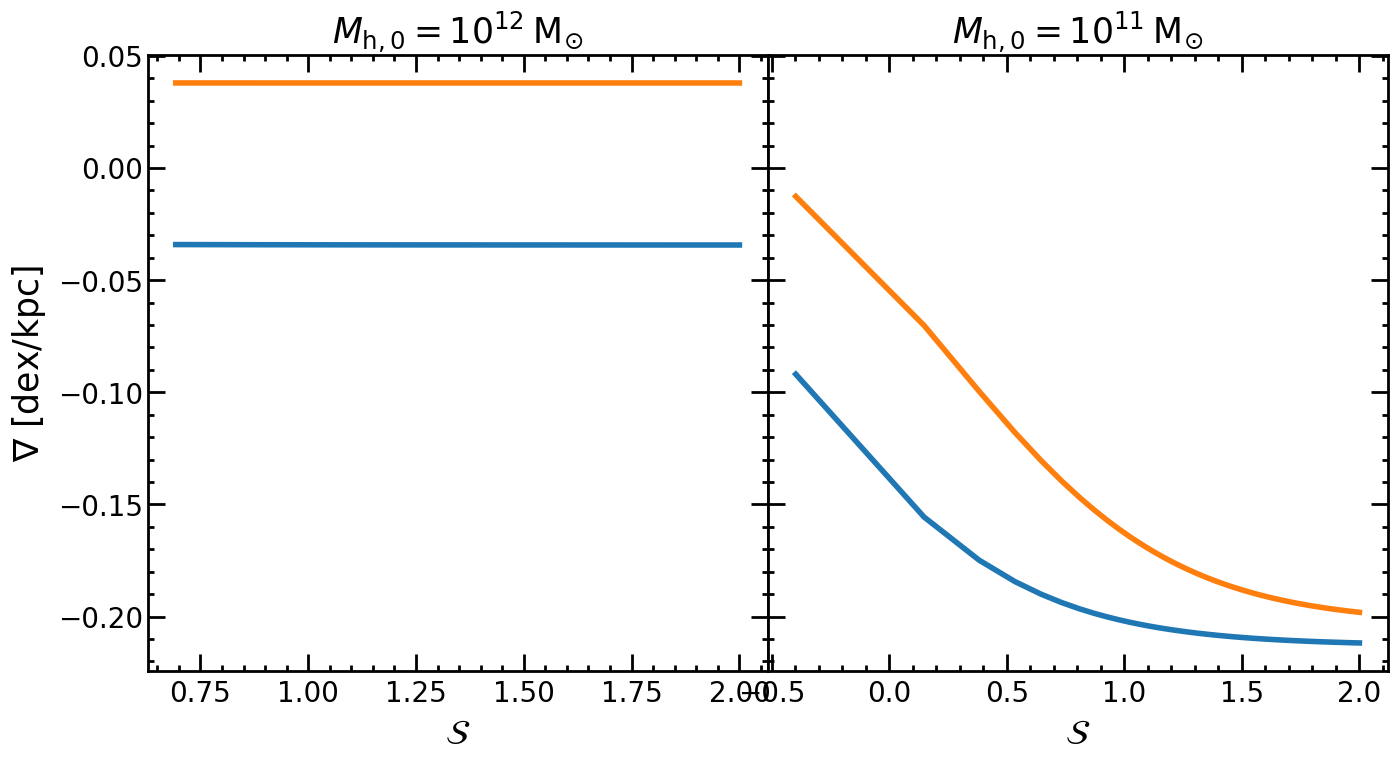

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(16,8), sharey = True)

metgrad_ineq_Mh01e12_varyS_min = []
metgrad_ineq_Mh01e12_varyS_max = []

metgrad_ineq_Mh01e11_varyS_min = []
metgrad_ineq_Mh01e11_varyS_max = []

for S_Mh01e12, S_Mh01e11 in zip(S_Mh01e12_arr, S_Mh01e11_arr):
    metgrad_ineq_Mh01e12_varyS_min.append(metgrad_ineq_Mh01e12_varyS[S_Mh01e12][0])
    metgrad_ineq_Mh01e12_varyS_max.append(metgrad_ineq_Mh01e12_varyS[S_Mh01e12][1])

    metgrad_ineq_Mh01e11_varyS_min.append(metgrad_ineq_Mh01e11_varyS[S_Mh01e11][0])
    metgrad_ineq_Mh01e11_varyS_max.append(metgrad_ineq_Mh01e11_varyS[S_Mh01e11][1])

ax[0].plot(np.log10(S_Mh01e12_arr), metgrad_ineq_Mh01e12_varyS_min)
ax[0].plot(np.log10(S_Mh01e12_arr), metgrad_ineq_Mh01e12_varyS_max)
ax[0].set_title(r'$M_{\mathrm{h,0}}=10^{12}\:\rm M_{\odot}$')
ax[0].set_ylabel(r'$\nabla$ [dex/kpc]')
ax[0].set_xlabel(r'$\mathcal{S}$')

ax[1].plot(np.log10(S_Mh01e11_arr), metgrad_ineq_Mh01e11_varyS_min)
ax[1].plot(np.log10(S_Mh01e11_arr), metgrad_ineq_Mh01e11_varyS_max)
ax[1].set_title(r'$M_{\mathrm{h,0}}=10^{11}\:\rm M_{\odot}$')
ax[1].set_xlabel(r'$\mathcal{S}$')

plt.subplots_adjust(wspace=0)
plt.show(True)

In [23]:
print(metgrad_ineq_Mh01e11_varyP_min[0])
print(metgrad_ineq_Mh01e11_varyS_min[0])
print(metgrad_ineq_Mh01e11_varyA_min[0])

-0.09193364770162425
-0.09193364770162425
-0.09193364770162425


In [35]:
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 0
matplotlib.rcParams['agg.path.chunksize'] = 10000

C:\Users\melec\AppData\Local\Temp\ipykernel_16984\1324536992.py:37: RuntimeWarning: divide by zero encountered in log10
  ax[0,0].plot(np.log10(P_Mh01e12_arr), metgrad_ineq_Mh01e12_varyP_min, color='black')
C:\Users\melec\AppData\Local\Temp\ipykernel_16984\1324536992.py:38: RuntimeWarning: divide by zero encountered in log10
  ax[0,0].plot(np.log10(P_Mh01e12_arr), metgrad_ineq_Mh01e12_varyP_max, color='black', linestyle='--')


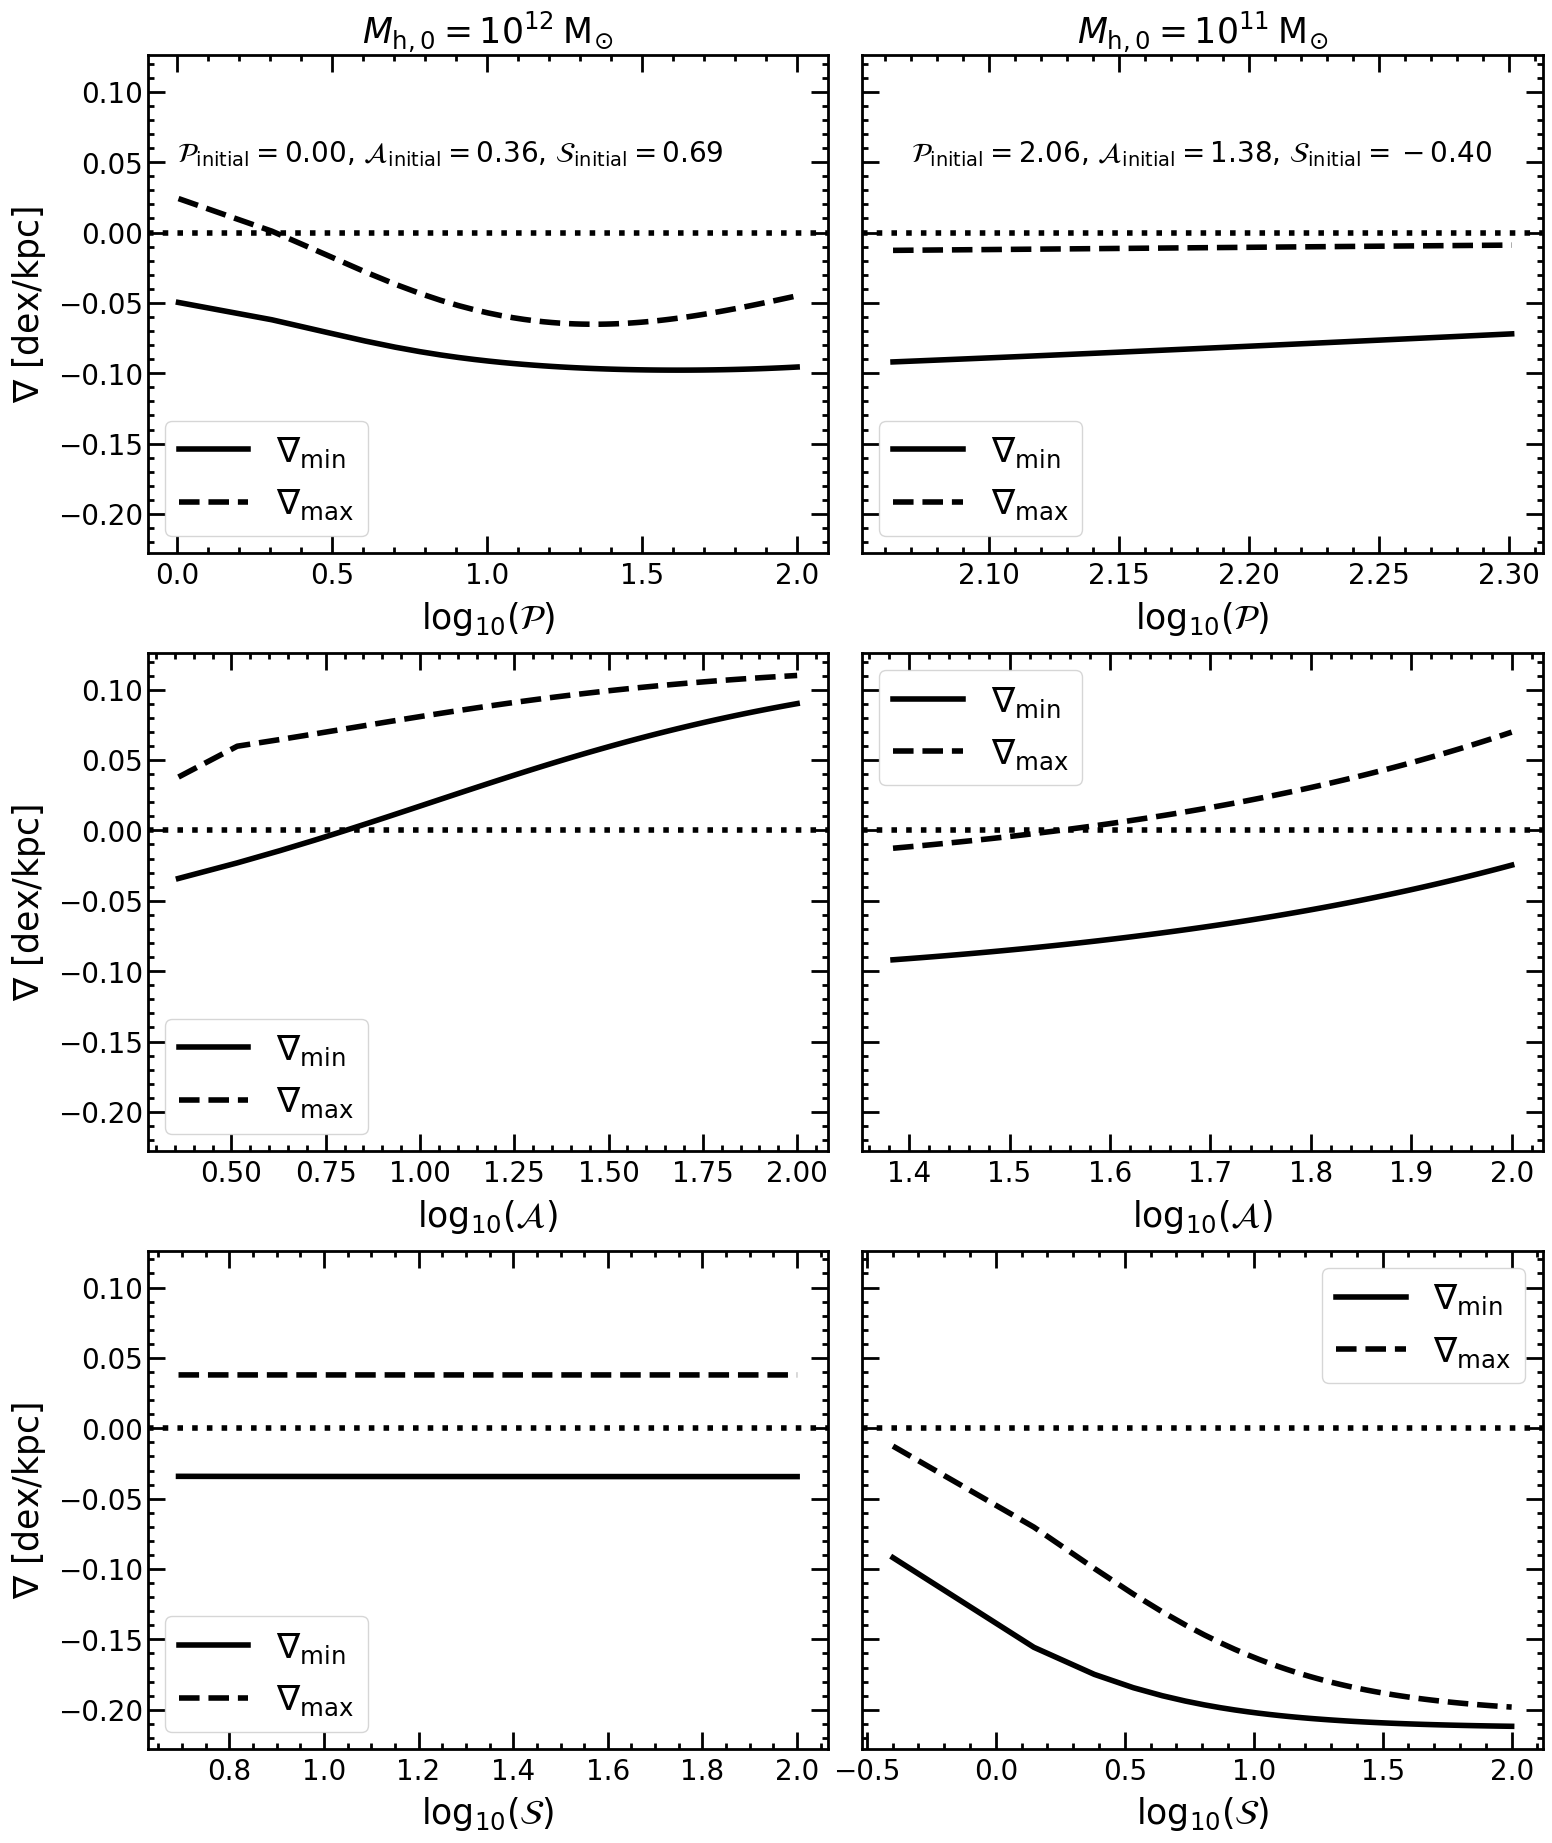

In [45]:
# z_arr = disk_outputs_Mh01e12_originalMdotacc_HH17['z']
# z_given = 0
# z_index = np.abs(z_arr-z_given).argmin()

P_Mh01e12_initial = disk_outputs_Mh01e12_originalMdotacc_HH17['P'][-1]
P_Mh01e11_initial = disk_outputs_Mh01e11_originalMdotacc_HH17['P'][-1]

A_Mh01e12_initial = disk_outputs_Mh01e12_originalMdotacc_HH17['A'][-1]
A_Mh01e11_initial = disk_outputs_Mh01e11_originalMdotacc_HH17['A'][-1]

S_Mh01e12_initial = disk_outputs_Mh01e12_originalMdotacc_HH17['Sprime_Toomre'][-1] * (1*0.028/0.0134) # Multiply Sprime_Toomre by phiy*y/solarZ
S_Mh01e11_initial = disk_outputs_Mh01e11_originalMdotacc_HH17['Sprime_Toomre'][-1] * (1*0.028/0.0134) # Multiply Sprime_Toomre by phiy*y/solarZ


fig, ax = plt.subplots(3, 2, figsize=(18,22), sharey = True)

gradmin_legend = mlines.Line2D([], [], color='black', label=r'$\nabla_{\rm min}$')
gradmax_legend = mlines.Line2D([], [], color='black', linestyle='--', label=r'$\nabla_{\rm max}$')
handles = [gradmin_legend, gradmax_legend]

# -------------- P ------------------ # 
metgrad_ineq_Mh01e12_varyP_min = []
metgrad_ineq_Mh01e12_varyP_max = []

metgrad_ineq_Mh01e11_varyP_min = []
metgrad_ineq_Mh01e11_varyP_max = []

for P_Mh01e12, P_Mh01e11 in zip(P_Mh01e12_arr, P_Mh01e11_arr):
    metgrad_ineq_Mh01e12_varyP_min.append(metgrad_ineq_Mh01e12_varyP[P_Mh01e12][0])
    metgrad_ineq_Mh01e12_varyP_max.append(metgrad_ineq_Mh01e12_varyP[P_Mh01e12][1])

    metgrad_ineq_Mh01e11_varyP_min.append(metgrad_ineq_Mh01e11_varyP[P_Mh01e11][0])
    metgrad_ineq_Mh01e11_varyP_max.append(metgrad_ineq_Mh01e11_varyP[P_Mh01e11][1])

np.array(P_Mh01e12)[np.array(P_Mh01e12) == 0.] = 0.01 

ax[0,0].plot(np.log10(P_Mh01e12_arr), metgrad_ineq_Mh01e12_varyP_min, color='black')
ax[0,0].plot(np.log10(P_Mh01e12_arr), metgrad_ineq_Mh01e12_varyP_max, color='black', linestyle='--')
# ax[0].fill_between(P_Mh01e12_arr, metgrad_ineq_Mh01e12_varyP_min, metgrad_ineq_Mh01e12_varyP_max, color='tab:olive', alpha = 0.5)
ax[0,0].set_title(r'$M_{\mathrm{h,0}}=10^{12}\:\rm M_{\odot}$')
ax[0,0].set_ylabel(r'$\nabla$ [dex/kpc]')
ax[0,0].set_xlabel(r'log$_{10}(\mathcal{P})$')
ax[0,0].text(0, 0.05, rf'$\mathcal{{P}}_{{\rm initial}}={P_Mh01e12_initial:.2f}$, $\mathcal{{A}}_{{\rm initial}}={np.log10(A_Mh01e12_initial):.2f}$, $\mathcal{{S}}_{{\rm initial}}={np.log10(S_Mh01e12_initial):.2f}$', fontsize=20)
ax[0,0].axhline(0, color='black', linestyle=':')
# ax[0,0].axvspan(ax[0,0].get_xlim()[0], 1, color = 'grey', alpha = 0.5)
ax[0,0].legend(handles=handles, loc='best')

ax[0,1].plot(np.log10(P_Mh01e11_arr), metgrad_ineq_Mh01e11_varyP_min, color='black')
ax[0,1].plot(np.log10(P_Mh01e11_arr), metgrad_ineq_Mh01e11_varyP_max, color='black', linestyle='--')
ax[0,1].set_title(r'$M_{\mathrm{h,0}}=10^{11}\:\rm M_{\odot}$')
ax[0,1].set_xlabel(r'log$_{10}(\mathcal{P})$')
ax[0,1].text(2.07, 0.05, rf'$\mathcal{{P}}_{{\rm initial}}={np.log10(P_Mh01e11_initial):.2f}$, $\mathcal{{A}}_{{\rm initial}}={np.log10(A_Mh01e11_initial):.2f}$, $\mathcal{{S}}_{{\rm initial}}={np.log10(S_Mh01e11_initial):.2f}$', fontsize=20)
ax[0,1].legend(handles=handles, loc='best')
ax[0,1].axhline(0, color='black', linestyle=':')


# -------------- A ------------------ # 
metgrad_ineq_Mh01e12_varyA_min = []
metgrad_ineq_Mh01e12_varyA_max = []

metgrad_ineq_Mh01e11_varyA_min = []
metgrad_ineq_Mh01e11_varyA_max = []

for A_Mh01e12, A_Mh01e11 in zip(A_Mh01e12_arr, A_Mh01e11_arr):
    metgrad_ineq_Mh01e12_varyA_min.append(metgrad_ineq_Mh01e12_varyA[A_Mh01e12][0])
    metgrad_ineq_Mh01e12_varyA_max.append(metgrad_ineq_Mh01e12_varyA[A_Mh01e12][1])

    metgrad_ineq_Mh01e11_varyA_min.append(metgrad_ineq_Mh01e11_varyA[A_Mh01e11][0])
    metgrad_ineq_Mh01e11_varyA_max.append(metgrad_ineq_Mh01e11_varyA[A_Mh01e11][1])

ax[1,0].plot(np.log10(A_Mh01e12_arr), metgrad_ineq_Mh01e12_varyA_min, color='black')
ax[1,0].plot(np.log10(A_Mh01e12_arr), metgrad_ineq_Mh01e12_varyA_max, color='black', linestyle='--')
ax[1,0].set_ylabel(r'$\nabla$ [dex/kpc]')
ax[1,0].set_xlabel(r'log$_{10}(\mathcal{A})$')
# ax[1,0].text(2.07, -0.22, rf'$\mathcal{{P}}_{{\rm initial}}={P_Mh01e12_initial:.2f}$, $\mathcal{{A}}_{{\rm initial}}={A_Mh01e12_initial:.2f}$, $\mathcal{{S}}_{{\rm initial}}={S_Mh01e12_initial:.2f}$', fontsize=23)
ax[1,0].legend(handles=handles, loc='best')
ax[1,0].axhline(0, color='black', linestyle=':')

ax[1,1].plot(np.log10(A_Mh01e11_arr), metgrad_ineq_Mh01e11_varyA_min, color='black')
ax[1,1].plot(np.log10(A_Mh01e11_arr), metgrad_ineq_Mh01e11_varyA_max, color='black', linestyle='--')
ax[1,1].set_xlabel(r'log$_{10}(\mathcal{A})$')
#ax[1,1].text(0, -0.22, rf'$\mathcal{{P}}_{{\rm initial}}={P_Mh01e11_initial:.2f}$, $\mathcal{{A}}_{{\rm initial}}={A_Mh01e11_initial:.2f}$, $\mathcal{{S}}_{{\rm initial}}={S_Mh01e11_initial:.2f}$', fontsize=23)
ax[1,1].legend(handles=handles, loc='best')
ax[1,1].axhline(0, color='black', linestyle=':')
    
# -------------- S ------------------ # 
metgrad_ineq_Mh01e12_varyS_min = []
metgrad_ineq_Mh01e12_varyS_max = []

metgrad_ineq_Mh01e11_varyS_min = []
metgrad_ineq_Mh01e11_varyS_max = []

for S_Mh01e12, S_Mh01e11 in zip(S_Mh01e12_arr, S_Mh01e11_arr):
    metgrad_ineq_Mh01e12_varyS_min.append(metgrad_ineq_Mh01e12_varyS[S_Mh01e12][0])
    metgrad_ineq_Mh01e12_varyS_max.append(metgrad_ineq_Mh01e12_varyS[S_Mh01e12][1])

    metgrad_ineq_Mh01e11_varyS_min.append(metgrad_ineq_Mh01e11_varyS[S_Mh01e11][0])
    metgrad_ineq_Mh01e11_varyS_max.append(metgrad_ineq_Mh01e11_varyS[S_Mh01e11][1])

ax[2,0].plot(np.log10(S_Mh01e12_arr), metgrad_ineq_Mh01e12_varyS_min, color='black')
ax[2,0].plot(np.log10(S_Mh01e12_arr), metgrad_ineq_Mh01e12_varyS_max, color='black', linestyle='--')
ax[2,0].set_ylabel(r'$\nabla$ [dex/kpc]')
ax[2,0].set_xlabel(r'log$_{10}(\mathcal{S})$')
#ax[2,0].text(0, 0.16, rf'$\mathcal{{P}}_{{\rm initial}}={P_Mh01e12_initial:.2f}$, $\mathcal{{A}}_{{\rm initial}}={A_Mh01e12_initial:.2f}$, $\mathcal{{S}}_{{\rm initial}}={S_Mh01e12_initial:.2f}$', fontsize=20)
ax[2,0].legend(handles=handles, loc='best')
ax[2,0].axhline(0, color='black', linestyle=':')


ax[2,1].plot(np.log10(S_Mh01e11_arr), metgrad_ineq_Mh01e11_varyS_min, color='black')
ax[2,1].plot(np.log10(S_Mh01e11_arr), metgrad_ineq_Mh01e11_varyS_max, color='black', linestyle='--')
ax[2,1].set_xlabel(r'log$_{10}(\mathcal{S})$')
#ax[2,1].text(0, 0.16, rf'$\mathcal{{P}}_{{\rm initial}}={P_Mh01e11_initial:.2f}$, $\mathcal{{A}}_{{\rm initial}}={A_Mh01e11_initial:.2f}$, $\mathcal{{S}}_{{\rm initial}}={S_Mh01e11_initial:.2f}$', fontsize=20)
ax[2,1].legend(handles=handles, loc='best')
ax[2,1].axhline(0, color='black', linestyle=':')

# for axes in fig.get_axes():
#     axes.set_xscale('log')

plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.savefig('figures/metallicity_figures/metgradvsPSA_Mh01e12Mh01e11_z=0_Mdotacc=original_etaw=0.pdf', dpi=600, bbox_inches='tight')
plt.show(True)